## Import and get the data

In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
ROBOFLOW_KEY = user_secrets.get_secret("roboflow_key")

In [2]:
!pip install -Uq roboflow

from roboflow import Roboflow

# Initialize with your API key
rf = Roboflow(api_key=ROBOFLOW_KEY)

# Access the project workspace
project = rf.workspace("cv-1dnsy").project("birds-planes-drones-detector")

# Download version 1 directly
version = project.version(22)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 104.1 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Birds,-Planes,-Drones-Detector-22 in coco:: 100%|██████████| 4928/4928 [00:01<00:00, 4597.60it/s]


In [3]:
from tqdm.auto import tqdm
import requests
from PIL import Image
import torch
import torchvision
from torch import nn
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import v2 as T
from torchvision.datasets import CocoDetection
from torch.utils.data import DataLoader # Subset

In [4]:
SEED = 42
EPOCHS = 5
BATCH = 4
device = 'cuda' if torch.cuda.is_available() else "cpu"

torch.random.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

## Dataset

In [5]:
transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    #T.Resize((640, 640), antialias=True)
])

In [6]:
class CocoDataset(CocoDetection):
   def __getitem__(self, index):
      # get the image and annotations
      img, annots = super().__getitem__(index)

      # get the index
      image_id = self.ids[index]

      return img, annots, image_id

In [7]:
train_data = CocoDataset(
   root="Birds,-Planes,-Drones-Detector-22/train",
   annFile='Birds,-Planes,-Drones-Detector-22/train/_annotations.coco.json',
   transform=transform
)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [8]:
def collate_fn(batch):

    images = []
    targets = []

    for image, annotations, image_id in batch:

        boxes = []
        labels = []

        for ann in annotations:

            x, y, w, h = ann["bbox"]

            # COCO → torchvision format
            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h

            boxes.append([
                x1, y1, x2, y2
            ])

            labels.append(
                ann["category_id"]
            )

        target = {
            "boxes": torch.tensor(
                boxes,
                dtype=torch.float32
            ),

            "labels": torch.tensor(
                labels,
                dtype=torch.int64
            ),

            # Preserve COCO image ID
            "image_id": torch.tensor(image_id),

            "iscrowd": torch.tensor(
               [ann["iscrowd"] for ann in annotations]
            ),

            "area": torch.tensor(
              [ann["area"] for ann in annotations]
            )
        }

        images.append(image)
        targets.append(target)

    return images, targets

In [9]:
train_loader = DataLoader(
   train_data,
   batch_size=BATCH,
   shuffle=False,
   pin_memory=True,
   collate_fn=collate_fn
)

In [10]:
for img, annots in train_loader:

    print([ann["image_id"] for ann in annots])

    break

[tensor(0), tensor(1), tensor(2), tensor(3)]


In [11]:
color_code = {
    0: "#FF7F0E",  # orange
    1: "#D62728",  # red
    2: "#9467BD",  # purple
    3: "#8C564B",  # brown
}

In [12]:
id_to_name = {i: j["name"] for i, j in train_data.coco.cats.items()}

In [13]:
id_to_name

{0: 'drones-planes-birds', 1: 'Airplane', 2: 'Bird', 3: 'Drone'}

In [14]:
num_classes = len(train_data.coco.cats.items())

In [15]:
import matplotlib.pyplot as plt
from matplotlib import patches


def visualize(img, target):
   fig, ax = plt.subplots(1, figsize=(10, 8))

   ax.imshow(
    img.permute(1, 2, 0).cpu().detach().numpy()
   )
   for tar in target:
     if len(tar["bbox"]) > 0:
      x1, y1, w, h = tar["bbox"][0] if isinstance(tar["bbox"][0], list) else tar["bbox"]
      obj_id = tar["category_id"]

      rectangle = patches.Rectangle(
         (x1, y1),
         w, h,
         linewidth=2,
         edgecolor=color_code[obj_id],
         facecolor='none'
        )
      ax.add_patch(rectangle)
      ax.text(x1, y1 - 5, f"{id_to_name[obj_id]}", color=color_code[obj_id], fontsize=12, bbox=dict(facecolor="white", alpha=0.5))


   plt.axis("off")
   plt.show()

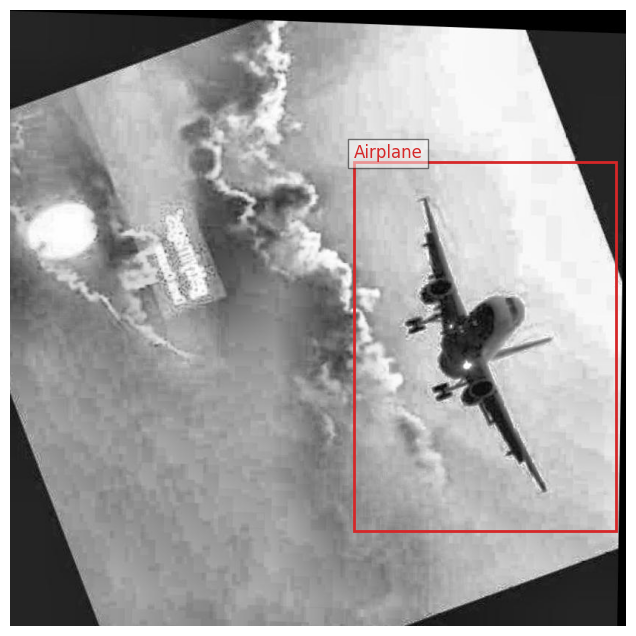

In [16]:
img, target, _ = train_data[-1]

visualize(img, target)

In [17]:
target

[{'id': 5208,
  'image_id': 4520,
  'category_id': 1,
  'bbox': [464, 205, 353.678, 498.126],
  'area': 176176.321,
  'segmentation': [],
  'iscrowd': 0}]

## Load model

In [18]:
model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT).to(device)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
).to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 214MB/s]


## dummy forward pass

In [19]:
images, targets = next(iter(train_loader))

images = [
    image.to(device)
    for image in images
]

targets = [
    {
        k: v.to(device)
        for k, v in target.items()
    }
    for target in targets
]
with torch.no_grad():
    loss_dict = model(images, targets)

In [20]:
loss_dict

{'loss_classifier': tensor(1.7276, device='cuda:0'),
 'loss_box_reg': tensor(0.0741, device='cuda:0'),
 'loss_objectness': tensor(0.0646, device='cuda:0'),
 'loss_rpn_box_reg': tensor(0.0287, device='cuda:0')}

## Train

In [21]:
params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

In [22]:
model.train()

total_loss = 0
for epoch in range(EPOCHS):
    pbar = tqdm(train_loader, desc=f"Epoch: {epoch}")
    for i, (images, targets) in enumerate(pbar, 1):

        images = [
            image.to(device, non_blocking=True)
            for image in images
        ]

        targets = [
            {
                k: v.to(device, non_blocking=True)
                for k, v in target.items()
            }
            for target in targets
        ]

        loss_dict = model(images, targets)

        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        mean_loss = total_loss / i
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "avg loss": mean_loss})


    print(
        f"Epoch {epoch + 1}: "
        f"loss = {total_loss / len(train_loader)}"
    )

print("Training complete!")

Epoch: 0:   0%|          | 0/1131 [00:00<?, ?it/s]

Epoch 1: loss = 0.1713343642645447


Epoch: 1:   0%|          | 0/1131 [00:00<?, ?it/s]

Epoch 2: loss = 0.2899481331407497


Epoch: 2:   0%|          | 0/1131 [00:00<?, ?it/s]

Epoch 3: loss = 0.38734400904120647


Epoch: 3:   0%|          | 0/1131 [00:00<?, ?it/s]

Epoch 4: loss = 0.470981565970272


Epoch: 4:   0%|          | 0/1131 [00:00<?, ?it/s]

Epoch 5: loss = 0.5485253813145411
Training complete!


## Eval

In [23]:
val_data = CocoDataset(
   root="Birds,-Planes,-Drones-Detector-22/valid",
   annFile='Birds,-Planes,-Drones-Detector-22/valid/_annotations.coco.json',
   transforms=transform
)

val_loader = DataLoader(
     val_data,
     batch_size=8,
     shuffle=False,
     pin_memory=True,
     collate_fn=collate_fn
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [24]:
@torch.no_grad()
def predict(img, threshold=0.5):
  """ Predict for the image """
  model.eval()

  image = img.unsqueeze(0).to(device)
  pred = model(image)[0]
  predictions = []
    
  indices = pred["scores"] >= threshold
  labels = pred["labels"][indices].tolist()
  boxes = pred["boxes"][indices].tolist()
  scores = pred["scores"][indices].tolist()
    
  for (label, box, score) in zip(labels, boxes[0], scores):
     p =  {
       "category_id": label,
       "bbox": [[x1, y1, x2 - x1, y2 - y1] for x1, y1, x2, y2 in boxes],
       "score": scores
     }
     predictions.append(p)

  return predictions

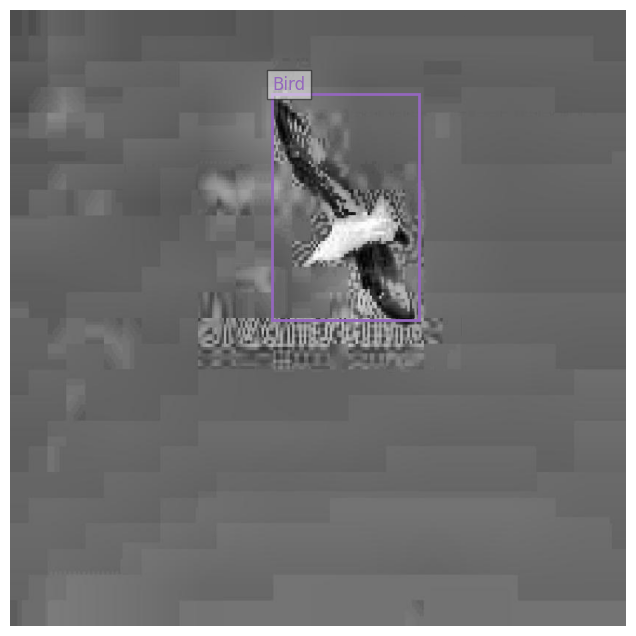

In [25]:
img, _, _ = train_data[-100]
pred = predict(img, 0.5)

visualize(img, pred)

In [26]:
pred

[{'category_id': 2,
  'bbox': [[353.8511962890625,
    112.2800521850586,
    198.27996826171875,
    306.22400665283203]],
  'score': [0.9927743673324585]}]

In [27]:
model.eval()

all_predictions = []
all_image_ids = []

with torch.no_grad():

    for images, targets in tqdm(
        val_loader,
        desc="Evaluating"
    ):
        images = [
            img.to(device)
            for img in images
        ]

        predictions = model(images)

        all_predictions.extend(predictions)

        all_image_ids.extend([
            target["image_id"].item()
            for target in targets
        ])

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

In [28]:
def to_coco_results(predictions, image_ids, threshold=0.5):

    results = []

    for prediction, image_id in zip(
        predictions,
        image_ids
    ):
        keep = prediction["scores"] >= threshold
        boxes = prediction["boxes"][keep].cpu()
        labels = prediction["labels"][keep].cpu()
        scores = prediction["scores"][keep].cpu()

        for box, label, score in zip(
            boxes,
            labels,
            scores
        ):
            x1, y1, x2, y2 = box.tolist()

            results.append({
                "image_id": int(image_id),
                "category_id": int(label),
                "bbox": [
                    x1,
                    y1,
                    x2 - x1,
                    y2 - y1
                ],
                "score": float(score)
            })

    return results

In [29]:
coco_results = to_coco_results(
    all_predictions,
    all_image_ids,
    0.3
)

print("Predictions:", len(coco_results))
print(coco_results[:2])

Predictions: 239
[{'image_id': 0, 'category_id': 1, 'bbox': [271.79083251953125, 317.2474060058594, 284.3514404296875, 178.84893798828125], 'score': 0.9890561103820801}, {'image_id': 2, 'category_id': 3, 'bbox': [352.24798583984375, 370.09588623046875, 45.7901611328125, 59.914825439453125], 'score': 0.9818595051765442}]


In [30]:
from pycocotools.cocoeval import COCOeval

coco_gt = val_data.coco
coco_dt = coco_gt.loadRes(
  coco_results
)

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!


In [31]:
coco_eval = COCOeval(
    coco_gt,
    coco_dt,
    iouType="bbox"
)

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.510
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.859
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.548
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.174
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.407
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.565
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.562
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.583
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.583
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.191
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100

## Try with images from the internet

![Plane Image](https://cdn.pixabay.com/photo/2023/07/11/03/27/aircraft-8119477_640.jpg)

![Bird Image](https://cdn.pixabay.com/photo/2017/03/13/10/25/hummingbird-2139278_1280.jpg)

![Drone Image](https://media.istockphoto.com/id/871275082/photo/flying-drone-at-night.jpg?s=612x612&w=0&k=20&c=XJkbG7AsYNpW1uYvxMqoJH6IfBR-CirGJjDQUYuu7Gc=)

In [32]:
urls = [
  "https://cdn.pixabay.com/photo/2023/07/11/03/27/aircraft-8119477_640.jpg",
  "https://cdn.pixabay.com/photo/2017/03/13/10/25/hummingbird-2139278_1280.jpg",
  "https://media.istockphoto.com/id/871275082/photo/flying-drone-at-night.jpg?s=612x612&w=0&k=20&c=XJkbG7AsYNpW1uYvxMqoJH6IfBR-CirGJjDQUYuu7Gc="
]

headers = {
  "user-agent": "Learner"
}

for i, url in enumerate(urls, 1):
   res = requests.get(url, headers=headers)

   with open(f"{i}.jpg", "wb") as f:
     f.write(res.content)

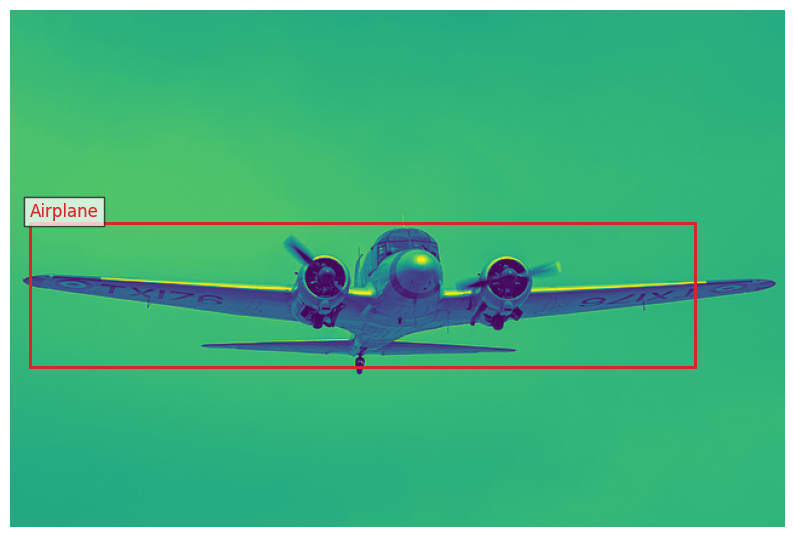

In [33]:
airplane = Image.open("1.jpg").convert("L")

result = predict(transform(airplane))
visualize(transform(airplane), result)

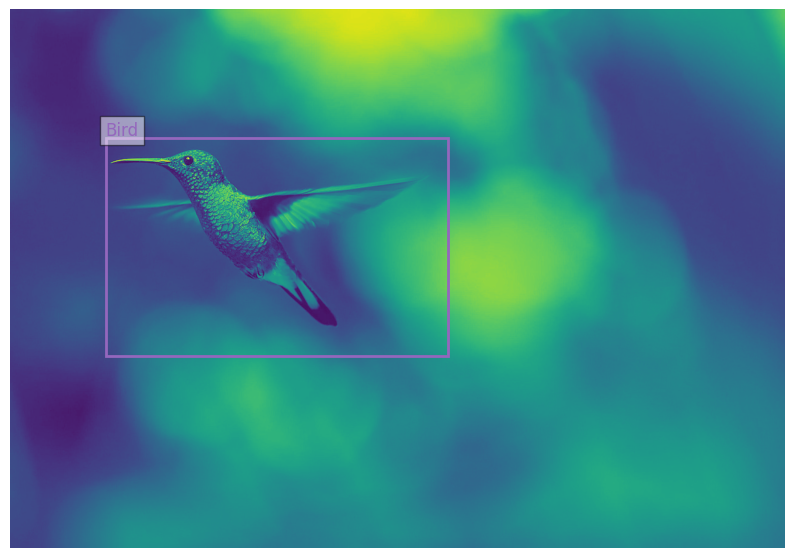

In [34]:
bird = Image.open("2.jpg").convert("L")

result = predict(transform(bird))
visualize(transform(bird), result)

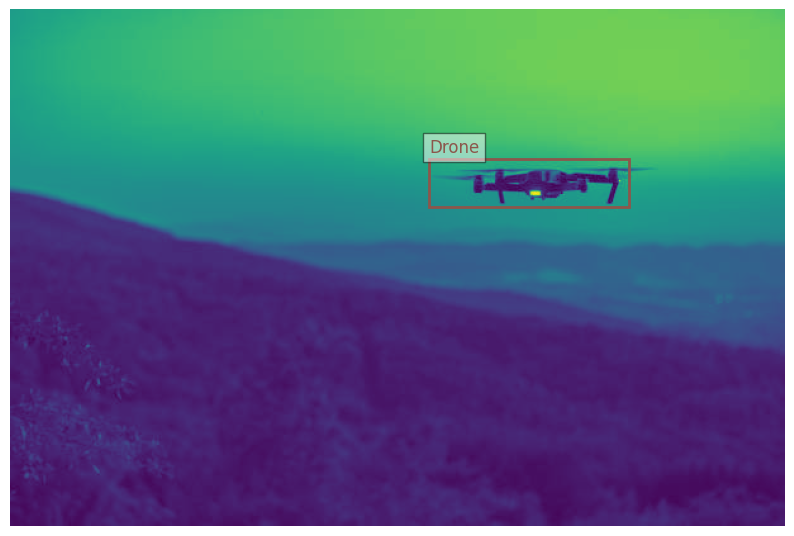

In [35]:
drone = Image.open("3.jpg").convert("L")

result = predict(transform(drone), threshold=0.5)
visualize(transform(drone), result)

In [36]:
model.eval()
torch.save(model, "aerial_object_detection_resnet50.pt")
!rm -rf "Birds,-Planes,-Drones-Detector-22"